### 1.4.5.1. Free Spring/Mass Systems

$$
m\frac{d^2x}{dt^2} + \beta\frac{dx}{dt} + kx = 0
\;\Longleftrightarrow\;
\frac{d^2x}{dt^2} + 2\lambda\frac{dx}{dt} + \omega^2 x = 0,
\quad 2\lambda = \frac{\beta}{m},\ \omega^2 = \frac{k}{m} .
$$

**Explanation:**

A mass on a spring obeys Newton's second law with Hooke's restoring force $-kx$ and a damping force $-\beta x'$, giving a second-order [constant-coefficient](../04_Higher_Order_Linear_Equations/03_homogeneous_equations_with_constant_coefficients.ipynb) equation. With no damping ($\beta = 0$) it reduces to $x'' + \omega^2 x = 0$ — **simple harmonic motion** $x = c_1\cos\omega t + c_2\sin\omega t$ with natural frequency $\omega = \sqrt{k/m}$. With damping, the discriminant $\lambda^2 - \omega^2$ sets the regime: **overdamped** ($>0$, two real roots, no oscillation), **critically damped** ($=0$, repeated root), or **underdamped** ($<0$, decaying oscillation). This damped second-order oscillator is the canonical mechanical plant the [dynamics and control](../../../02_Dynamics) tracks linearize and stabilize.

**Intuition:**

<p align="center">
  <img src="../../../Figures/01040501_spring_mass_system.jpeg"
       alt="A spring/mass system with displacement measured from the equilibrium position"
       width="170">
</p>

**Numerical Example:**

**Free undamped.** A 2-lb weight stretches a spring 6 in. $= \tfrac12$ ft, so Hooke's law $2 = k(\tfrac12)$ gives $k = 4$ lb/ft, and $m = \tfrac{W}{g} = \tfrac{2}{32} = \tfrac{1}{16}$ slug. The equation $\tfrac{1}{16}x'' = -4x$ becomes

$$
x'' + 64x = 0, \qquad \omega = 8 .
$$

Released from $x(0) = \tfrac23$ ft (8 in. below) with upward velocity $x'(0) = -\tfrac43$, the general solution $x = c_1\cos 8t + c_2\sin 8t$ gives $c_1 = \tfrac23$ and $c_2 = -\tfrac16$:

$$
x(t) = \tfrac23\cos 8t - \tfrac16\sin 8t, \qquad \text{amplitude } A = \sqrt{(\tfrac23)^2 + (\tfrac16)^2} = \tfrac{\sqrt{17}}{6} \approx 0.69 \text{ ft}.
$$

**Free damped (overdamped).** For $x'' + 5x' + 4x = 0$, $x(0) = 1$, $x'(0) = 1$: the auxiliary equation $m^2 + 5m + 4 = (m+1)(m+4) = 0$ has real roots $-1, -4$ (here $\lambda = \tfrac52 > \omega = 2$, overdamped), so

$$
x(t) = \tfrac53 e^{-t} - \tfrac23 e^{-4t},
$$

a smooth, non-oscillatory decay to equilibrium.

In [1]:
import sympy as sp

t = sp.symbols("t")
x = sp.Function("x")

undamped = sp.dsolve(sp.Eq(x(t).diff(t, 2) + 64 * x(t), 0), x(t),
                     ics={x(0): sp.Rational(2, 3), x(t).diff(t).subs(t, 0): sp.Rational(-4, 3)})
amplitude = sp.sqrt(sp.Rational(2, 3)**2 + sp.Rational(1, 6)**2)

overdamped = sp.dsolve(sp.Eq(x(t).diff(t, 2) + 5 * x(t).diff(t) + 4 * x(t), 0), x(t),
                       ics={x(0): 1, x(t).diff(t).subs(t, 0): 1})

print("free undamped : x(t) =", undamped.rhs, "  amplitude =", sp.N(amplitude, 3), "ft")
print("overdamped    : x(t) =", overdamped.rhs)

free undamped : x(t) = -sin(8*t)/6 + 2*cos(8*t)/3   amplitude = 0.687 ft
overdamped    : x(t) = (5/3 - 2*exp(-3*t)/3)*exp(-t)


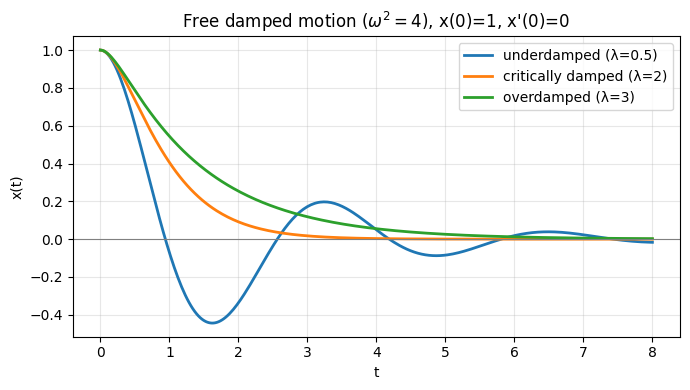

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def damped(damping):
    rhs = lambda time, state: [state[1], -4 * state[0] - 2 * damping * state[1]]
    return solve_ivp(rhs, (0, 8), [1, 0], t_eval=np.linspace(0, 8, 300))

regimes = {"underdamped (λ=0.5)": 0.5, "critically damped (λ=2)": 2.0, "overdamped (λ=3)": 3.0}
plt.figure(figsize=(7, 4))
for label, damping in regimes.items():
    result = damped(damping)
    plt.plot(result.t, result.y[0], linewidth=2, label=label)
plt.axhline(0, color="gray", linewidth=0.8)
plt.xlabel("t"); plt.ylabel("x(t)"); plt.title(r"Free damped motion ($\omega^2=4$), x(0)=1, x'(0)=0")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

**References:**

[📘 Zill, D. G. (2016). *A First Course in Differential Equations with Modeling Applications* (11th ed.). Cengage Learning.](https://www.cengage.com/c/a-first-course-in-differential-equations-with-modeling-applications-11e-zill/9781305965720/)

---

[⬅️ Previous: Cauchy-Euler Equations](../04_Higher_Order_Linear_Equations/06_cauchy_euler_equations.ipynb) | [Next: Driven Motion and Resonance ➡️](./02_driven_motion_and_resonance.ipynb)